# Desafio Ciência e Governança de Dados

Desenvolvido por Estevão Augusto da Fonseca Santos, Graduando em Ciência de Computação

6° Período da Universidade Federal de Lavras

## Objetivos

Após ter coletado os dados e ter passado pelo pré-processamento. É iniciado a Análise Exploratória, etapa essa em que se  investiga, entende e resume o conjunto de dados antes de aplicar modelos ou tirar conclusões definitivas

In [50]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os

In [51]:
DATA_DIRECTORY_PATH = "../data"
RAW_DATA_DIRECTORY_PATH = DATA_DIRECTORY_PATH + "/raw"
PROCESSED_DATA_DIRECTORY_PATH = DATA_DIRECTORY_PATH + "/processed"
METRICS_DIRECTORY_PATH = "../metrics"

In [52]:
if not os.path.isdir(METRICS_DIRECTORY_PATH):
    os.mkdir(METRICS_DIRECTORY_PATH)

## Análise Exploratória

In [53]:
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10,6)

### Carregar dados

In [54]:
df_municipios = pd.read_csv(PROCESSED_DATA_DIRECTORY_PATH + "/tamanho_populacional_mun.csv")
df_alfabetizacao = pd.read_csv(PROCESSED_DATA_DIRECTORY_PATH + "/alfabetizacao_processada.csv")
df_educacao = pd.read_csv(PROCESSED_DATA_DIRECTORY_PATH + "/educacao_basica_sexo_raca_cor.csv")
df_pib = pd.read_csv(RAW_DATA_DIRECTORY_PATH + "/pip_por_municipio.csv")

# Normalizar PIB e VA para milhões
df_pib["pib"] = df_pib["pib"] / 1_000_000
df_pib["va"] = df_pib["va"] / 1_000_000

In [55]:
print("## 1. Visão Geral e Estatísticas Descritivas")
# Informações básicas do DataFrame
print("\n--- Informações do DataFrame ---")
df_pib.info()
df_alfabetizacao.info()
df_educacao.info()
df_municipios.info()

# Estatísticas descritivas para colunas numéricas
print("\n--- Estatísticas Descritivas ---")
print(df_pib.describe())

## 1. Visão Geral e Estatísticas Descritivas

--- Informações do DataFrame ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5570 entries, 0 to 5569
Data columns (total 10 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   id_municipio       5570 non-null   int64  
 1   id_municipio_nome  5570 non-null   object 
 2   ano                5570 non-null   int64  
 3   pib                5570 non-null   float64
 4   impostos_liquidos  5570 non-null   int64  
 5   va                 5570 non-null   float64
 6   va_agropecuaria    5570 non-null   int64  
 7   va_industria       5570 non-null   int64  
 8   va_servicos        5570 non-null   int64  
 9   va_adespss         5570 non-null   int64  
dtypes: float64(2), int64(7), object(1)
memory usage: 435.3+ KB
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5570 entries, 0 to 5569
Data columns (total 3 columns):
 #   Column               Non-Null Count  Dtype 
---  ------        

### Filtrar Lavras

In [56]:
lavras_pop = df_municipios[df_municipios['id_municipio_nome'] == 'Lavras']
lavras_alf = df_alfabetizacao[df_alfabetizacao['id_municipio_nome'] == 'Lavras']
lavras_edu = df_educacao[df_educacao['id_municipio_nome'] == 'Lavras']
lavras_pib = df_pib[df_pib['id_municipio_nome'] == 'Lavras']

### Indicadores de Lavras

In [57]:
pop_lavras = lavras_pop['populacao_total'].values[0]
total_alfabetizados = lavras_alf['total_alfabetizados'].values[0]
taxa_alfabetizacao = total_alfabetizados / pop_lavras * 100
total_matriculas = lavras_edu['quantidade_matricula'].sum()
pib = lavras_pib['pib'].values[0]
va_total = lavras_pib['va'].values[0]

print(f"Populacao Lavras: {pop_lavras}")
print(f"Total Alfabetizados: {total_alfabetizados}")
print(f"Taxa Alfabetização: {taxa_alfabetizacao}")
print(f"Total Matriculas: {total_matriculas}")
print(f"Pib total: {pib}")
print(f"Valor bruto total: {va_total}")

Populacao Lavras: 105756
Total Alfabetizados: 84907
Taxa Alfabetização: 80.2857521086274
Total Matriculas: 20105
Pib total: 2941.931
Valor bruto total: 2572.287


### Indicadores do estado de MG

In [58]:
df_mg = df_municipios[df_municipios['NM_UF_SIGLA'] == 'MG']
pop_mg = df_mg['populacao_total'].sum()
proporcao_pop = pop_lavras / pop_mg * 100

# Taxa de alfabetização de todos os municípios de MG
df_mg_alf = df_alfabetizacao.merge(df_mg, on=['id_municipio', 'id_municipio_nome'])
df_mg_alf['taxa_alfabetizacao'] = df_mg_alf['total_alfabetizados'] / df_mg_alf['populacao_total'] * 100

# Ranking de Lavras em MG
rank_alf_mg = df_mg_alf['taxa_alfabetizacao'].rank(ascending=False)[df_mg_alf['id_municipio'] == lavras_pop['id_municipio'].values[0]].values[0]
rank_pop_mg = df_mg['populacao_total'].rank(ascending=False)[df_mg['id_municipio'] == lavras_pop['id_municipio'].values[0]].values[0]

print("Total de Alfabetizados em Minas Gerais:")
print(df_mg_alf['total_alfabetizados'])
print(f"Ranking de Lavras em MG:")
print(rank_alf_mg)
print(rank_pop_mg)

Total de Alfabetizados em Minas Gerais:
0       4979
1      17989
2      10727
3       2901
4       6317
       ...  
848     7681
849     3105
850    29926
851     3395
852     1863
Name: total_alfabetizados, Length: 853, dtype: int64
Ranking de Lavras em MG:
105.0
33.0


### Ranking Brasil

In [59]:
df_brasil = df_municipios.merge(df_alfabetizacao, on=['id_municipio', 'id_municipio_nome'])
df_brasil['taxa_alfabetizacao'] = df_brasil['total_alfabetizados'] / df_brasil['populacao_total'] * 100

rank_alf_brasil = df_brasil['taxa_alfabetizacao'].rank(ascending=False)[df_brasil['id_municipio'] == lavras_pop['id_municipio'].values[0]].values[0]
rank_pop_brasil = df_brasil['populacao_total'].rank(ascending=False)[df_brasil['id_municipio'] == lavras_pop['id_municipio'].values[0]].values[0]

print(f"Rank de alfabetização do Brasil: {rank_alf_brasil}")
print(f"Rank populacional do Brasil: {rank_pop_brasil}")

Rank de alfabetização do Brasil: 819.0
Rank populacional do Brasil: 308.0


### Indicadores Lavras

In [60]:
indicadores_lavras = pd.DataFrame({
    'id_municipio': [lavras_pop['id_municipio'].values[0]],
    'municipio': ['Lavras'],
    'populacao_total': [pop_lavras],
    'total_alfabetizados': [total_alfabetizados],
    'taxa_alfabetizacao': [taxa_alfabetizacao],
    'total_matriculas': [total_matriculas],
    'pib_milhoes': [pib],
    'va_total_milhoes': [va_total],
    'populacao_estado_mg': [pop_mg],
    'proporcao_pop_estado_mg': [proporcao_pop],
    'rank_alfabetizacao_mg': [rank_alf_mg],
    'rank_populacao_mg': [rank_pop_mg],
    'rank_alfabetizacao_brasil': [rank_alf_brasil],
    'rank_populacao_brasil': [rank_pop_brasil]
})

indicadores_lavras.to_csv(PROCESSED_DATA_DIRECTORY_PATH + "/indicadores_lavras_completo.csv", index=False)
print(indicadores_lavras)

   id_municipio municipio  populacao_total  total_alfabetizados  \
0       3138203    Lavras           105756                84907   

   taxa_alfabetizacao  total_matriculas  pib_milhoes  va_total_milhoes  \
0           80.285752             20105     2941.931          2572.287   

   populacao_estado_mg  proporcao_pop_estado_mg  rank_alfabetizacao_mg  \
0             21411923                 0.493912                  105.0   

   rank_populacao_mg  rank_alfabetizacao_brasil  rank_populacao_brasil  
0               33.0                      819.0                  308.0  


### Gráficos Comparativos

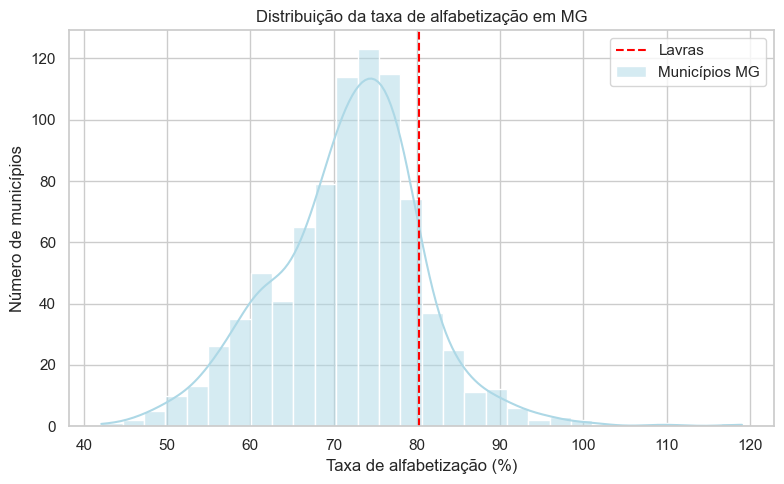

C:\Users\Maurício\AppData\Local\Temp\ipykernel_12580\3823681190.py:32: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


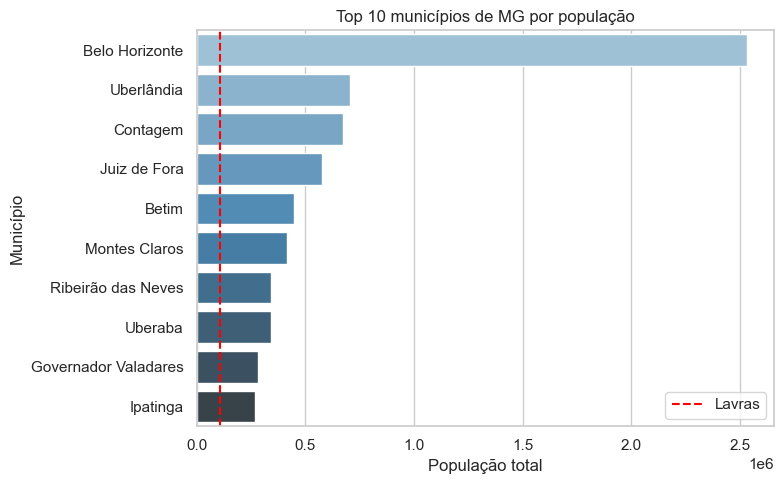

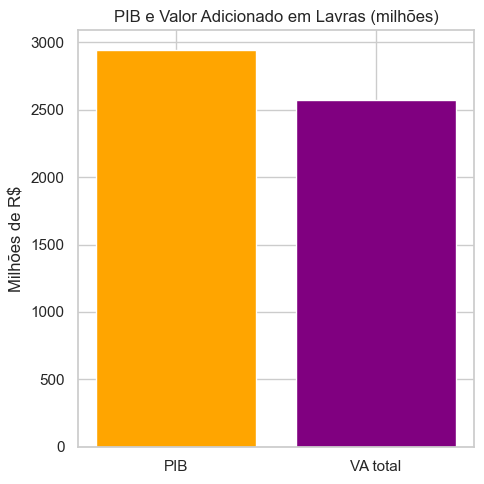

In [61]:
# -------------------------------
# 1. Taxa de alfabetização de Lavras vs MG
# -------------------------------
plt.figure(figsize=(8,5))
sns.histplot(
    df_mg_alf['taxa_alfabetizacao'],
    bins=30,
    kde=True,
    color='lightblue',
    label='Municípios MG'
)
plt.axvline(taxa_alfabetizacao, color='red', linestyle='--', label='Lavras')
plt.title('Distribuição da taxa de alfabetização em MG')
plt.xlabel('Taxa de alfabetização (%)')
plt.ylabel('Número de municípios')
plt.legend()
plt.tight_layout()
plt.savefig(os.path.join(METRICS_DIRECTORY_PATH + "/", 'taxa_alfabetizacao_lavras_vs_mg.png'), dpi=300, bbox_inches='tight')

plt.show()
plt.close()  # fecha a figura para não mostrar

# -------------------------------
# 2. População de Lavras vs top 10 municípios MG
# -------------------------------
top10_pop_mg = df_mg.sort_values('populacao_total', ascending=False).head(10)

# Criar lista de cores para cada barra
cores = sns.color_palette("Blues_d", n_colors=len(top10_pop_mg))

plt.figure(figsize=(8,5))
sns.barplot(
    data=top10_pop_mg,
    x='populacao_total',
    y='id_municipio_nome',
    palette=cores
)
plt.axvline(pop_lavras, color='red', linestyle='--', label='Lavras')
plt.title('Top 10 municípios de MG por população')
plt.xlabel('População total')
plt.ylabel('Município')
plt.legend()
plt.tight_layout()
plt.savefig(os.path.join(METRICS_DIRECTORY_PATH + "/", 'pop_lavras_vs_top10_mun_mg.png'), dpi=300, bbox_inches='tight')


plt.show()
plt.close()

# -------------------------------
# 3. PIB vs Valor Adicionado de Lavras
# -------------------------------
plt.figure(figsize=(5,5))
plt.bar(['PIB', 'VA total'], [pib, va_total], color=['orange','purple'])
plt.title('PIB e Valor Adicionado em Lavras (milhões)')
plt.ylabel('Milhões de R$')
plt.tight_layout()
plt.savefig(os.path.join(METRICS_DIRECTORY_PATH + "/", 'pib_vs_valor_adicionado_em_lavras.png'), dpi=300, bbox_inches='tight')


plt.show()
plt.close()